# DQN Learning Dynamics in the Prisoner's Dilemma

## Motivation

In (Goll, Heitzig & Barfuss, 2024) we showed that two tabular Q-learning agents playing the Prisoner's Dilemma exhibit complex learning dynamics — transient cooperation, metastable oscillations, and sensitive dependence on the discount factor $\gamma$ — all predicted by a deterministic mean-field model. A natural follow-up question is:

> **Do these dynamics persist when we replace the tabular Q-table with a neural network (DQN)?**

If the answer is yes, it tells us that the complex dynamics are a property of the *update rule* (incremental, bootstrapping TD-learning), not the tabular representation. We then ask a second question:

> **Does the experience replay buffer — a standard component of DQN — dampen or eliminate these dynamics?**

Standard DQN (Mnih et al., 2015) samples a batch of past experiences from a replay buffer, which decorrelates the training data from the current policy. In the multi-agent setting, this breaks the tight feedback loop where both agents simultaneously adapt to each other's most recent behaviour.

## Experimental Design

We compare four conditions, all in the two-player Prisoner's Dilemma with Boltzmann action selection:

| Condition | Algorithm | Replay Buffer | Batch Size | Expected Dynamics |
|---|---|---|---|---|
| Tabular Q-learning | Q-table update | — | — | Complex (baseline) |
| DQN (no replay) | Neural net, gradient descent | size 1 | 1 | Similar to tabular |
| DQN (buf=100) | Neural net, gradient descent | size 100 | 32 | Partially damped |
| DQN (buf=10k) | Neural net, gradient descent | size 10,000 | 32 | Strongly damped |

The DQN uses a small MLP (1 → 32 → 2) mapping a dummy constant input to two Q-values. With `buffer_size=1` and `batch_size=1`, the DQN update reduces to training on the current experience only — analogous to the tabular update but via gradient descent on the MSE loss.

## Setup

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import torch

# Import from local agent_game_sim.py (includes DQNAgent)
from agent_game_sim import (
    Game, 
    Simulation, 
    QLearningAgent,
    DQNAgent,
    reward_matrix_for_two_player_PD,
    generate_q_values
)

print("Setup complete!")
print(f"PyTorch version: {torch.__version__}")

Setup complete!
PyTorch version: 2.10.0


## Experiment Parameters

In [11]:
# ============================================================
# User-configurable parameters (change these as needed)
# ============================================================

SEED = 3
LEARNING_RATE = 0.01
TEMPERATURE = 1.0
BASE_VALUE = 0
INITIAL_PROBS = (0.5, 0.48)

# Number of time steps
NUM_STEPS_SHORT = 3000       # For gamma=0 (converges quickly)
NUM_STEPS_LONG = int(1e5)    # For gamma=0.8 (slower dynamics)

# Steady-state averaging starts from this time step
AVG_FROM = 50000

# Experiment configurations for γ=0.8
EXPERIMENT_CONFIGS = [
    {'type': 'tabular',                                    'label': 'Tabular Q-learning'},
    {'type': 'dqn', 'buffer_size': 1,     'batch_size': 1,  'label': 'DQN (no replay)'},
    {'type': 'dqn', 'buffer_size': 100,   'batch_size': 32, 'label': 'DQN (buf=100, batch=32)'},
    {'type': 'dqn', 'buffer_size': 10000, 'batch_size': 32, 'label': 'DQN (buf=10k, batch=32)'},
]

# ============================================================
# Structural constants (fixed by experiment design)
# ============================================================
num_players = 2
action_space = np.array([0, 1])  # 0 = cooperate, 1 = defect
observation_length = 0  # Stateless

print(f"Seed: {SEED}")
print(f"Initial probabilities: {INITIAL_PROBS}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Temperature: {TEMPERATURE}")

Seed: 3
Initial probabilities: (0.5, 0.48)
Learning rate: 0.01
Temperature: 1.0


## Helper Functions

In [12]:
def run_dqn_experiment(discount_factor, initial_probs, num_time_steps,
                       buffer_size=1, batch_size=1, seed=42):
    """
    Run a DQN experiment with two agents playing Prisoner's Dilemma.
    
    Args:
        buffer_size: Replay buffer size (1 = no replay, train on current experience only)
        batch_size: Experiences sampled per training step (1 = single experience)
    """
    np.random.seed(seed)
    torch.manual_seed(seed)
    
    agents = [
        DQNAgent(
            player_id=i,
            action_space=action_space,
            num_players=num_players,
            reward_func=reward_matrix_for_two_player_PD,
            learning_rate=LEARNING_RATE,
            discount_factor=discount_factor,
            temperature=TEMPERATURE,
            initial_prob=initial_probs[i],
            base_value=BASE_VALUE,
            use_prefactor=False,
            buffer_size=buffer_size,
            batch_size=batch_size
        )
        for i in range(num_players)
    ]
    
    game = Game(agents=agents)
    simulation = Simulation()
    simulation.run(game, agents, num_time_steps)
    
    prob_histories = []
    for agent in agents:
        probs = np.array([
            agent.get_action_probabilities(q_table)[0, 0]
            for q_table in agent.q_table_history
        ])
        prob_histories.append(probs)
    
    return {
        'prob_agent_0': prob_histories[0],
        'prob_agent_1': prob_histories[1],
        'agents': agents,
    }


def run_tabular_experiment(discount_factor, initial_probs, num_time_steps, seed=42):
    """
    Run a tabular Q-learning experiment for comparison.
    """
    np.random.seed(seed)
    
    initial_q_tables = [
        np.expand_dims(generate_q_values(prob, TEMPERATURE, BASE_VALUE), axis=0)
        for prob in initial_probs
    ]
    
    agents = [
        QLearningAgent(
            player_id=i,
            action_space=action_space,
            num_players=num_players,
            discount_factor=discount_factor,
            observation_length=observation_length,
            selection_method="Boltzmann",
            reward_func=reward_matrix_for_two_player_PD,
            temperature=TEMPERATURE,
            learning_rate=LEARNING_RATE,
            q_table=initial_q_tables[i],
            use_prefactor=False
        )
        for i in range(num_players)
    ]
    
    game = Game(agents=agents)
    simulation = Simulation()
    simulation.run(game, agents, num_time_steps)
    
    prob_histories = []
    for agent in agents:
        probs = np.array([
            agent.get_action_probabilities(q_table)[0, 0]
            for q_table in agent.q_table_history
        ])
        prob_histories.append(probs)
    
    return {
        'prob_agent_0': prob_histories[0],
        'prob_agent_1': prob_histories[1],
        'agents': agents
    }


def plot_comparison(results_dict, suptitle=None, save_path=None, avg_from=None):
    """
    Plot cooperation probabilities for multiple experiments.
    Each subplot shows one experiment with both agents (blue/orange).
    
    Args:
        results_dict: dict of {label: results} pairs
        suptitle: Overall figure title
        save_path: Path to save figure
        avg_from: Time step from which to compute and display the steady-state
                    average (e.g. 50000). If None, no average lines are shown.
    """
    n = len(results_dict)
    fig, axes = plt.subplots(n, 1, figsize=(12, 3 * n), sharex=True)
    if n == 1:
        axes = [axes]
    
    for ax, (label, results) in zip(axes, results_dict.items()):
        t_max = len(results['prob_agent_0'])
        
        ax.plot(results['prob_agent_0'], 
                color='C0', alpha=0.9, linewidth=1.5)
        ax.plot(results['prob_agent_1'], 
                color='C1', alpha=0.9, linewidth=1.5)
        
        # Build legend labels
        label_0 = 'Agent 1'
        label_1 = 'Agent 2'
        
        if avg_from is not None and avg_from < t_max:
            avg_0 = np.mean(results["prob_agent_0"][avg_from:])
            avg_1 = np.mean(results["prob_agent_1"][avg_from:])
            std_0 = np.std(results["prob_agent_0"][avg_from:])
            std_1 = np.std(results["prob_agent_1"][avg_from:])
            
            # Draw dashed average lines only in the averaging region
            ax.plot([avg_from, t_max], [avg_0, avg_0],
                    color="C0", linestyle="--", linewidth=1.5, alpha=0.8)
            ax.plot([avg_from, t_max], [avg_1, avg_1],
                    color="C1", linestyle="--", linewidth=1.5, alpha=0.8)
            
            label_0 = f'Agent 1   avg(t>{avg_from/1e3:.0f}k): {avg_0:.2f} ± {std_0:.2f}'
            label_1 = f'Agent 2   avg(t>{avg_from/1e3:.0f}k): {avg_1:.2f} ± {std_1:.2f}'
        
        # Invisible proxy artists for a clean legend
        ax.plot([], [], color='C0', linewidth=1.5, label=label_0)
        ax.plot([], [], color='C1', linewidth=1.5, label=label_1)
        
        ax.set_ylabel(f'$\\pi_C$', fontsize=11)
        ax.set_ylim(-0.05, 1.05)
        ax.set_title(label, fontsize=11)
        ax.grid(True, alpha=0.3)
        ax.legend(loc='upper right', fontsize=10, framealpha=0.9,
                  prop={'family': 'monospace'})
    
    def formatter(x, pos):
        return f'{x/1e3:.1f}'
    axes[-1].xaxis.set_major_formatter(FuncFormatter(formatter))
    axes[-1].set_xlabel('Time step $t$ [×$10^3$]', fontsize=11)
    
    if suptitle:
        fig.suptitle(suptitle, fontsize=12)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved to {save_path}")
    
    plt.show()


print("Helper functions defined.")

Helper functions defined.


## Experiment 1: γ = 0 (Sanity Check)

With $\gamma = 0$ the bootstrapping term $\gamma \max_a Q(a)$ vanishes and the Q-learning update reduces to a simple reward-averaging rule. There is no self-referential feedback, so both tabular and DQN should converge monotonically toward mutual defection (the dominant-strategy Nash equilibrium of the PD). This serves as a sanity check that the DQN implementation behaves correctly.

Running all γ=0 experiments (t=3000)...

Running Tabular Q-learning...
Running DQN (no replay)...
Running DQN (buf=100, batch=32)...
Running DQN (buf=10k, batch=32)...

Done.
Saved to figures/comparison_gamma_0.png


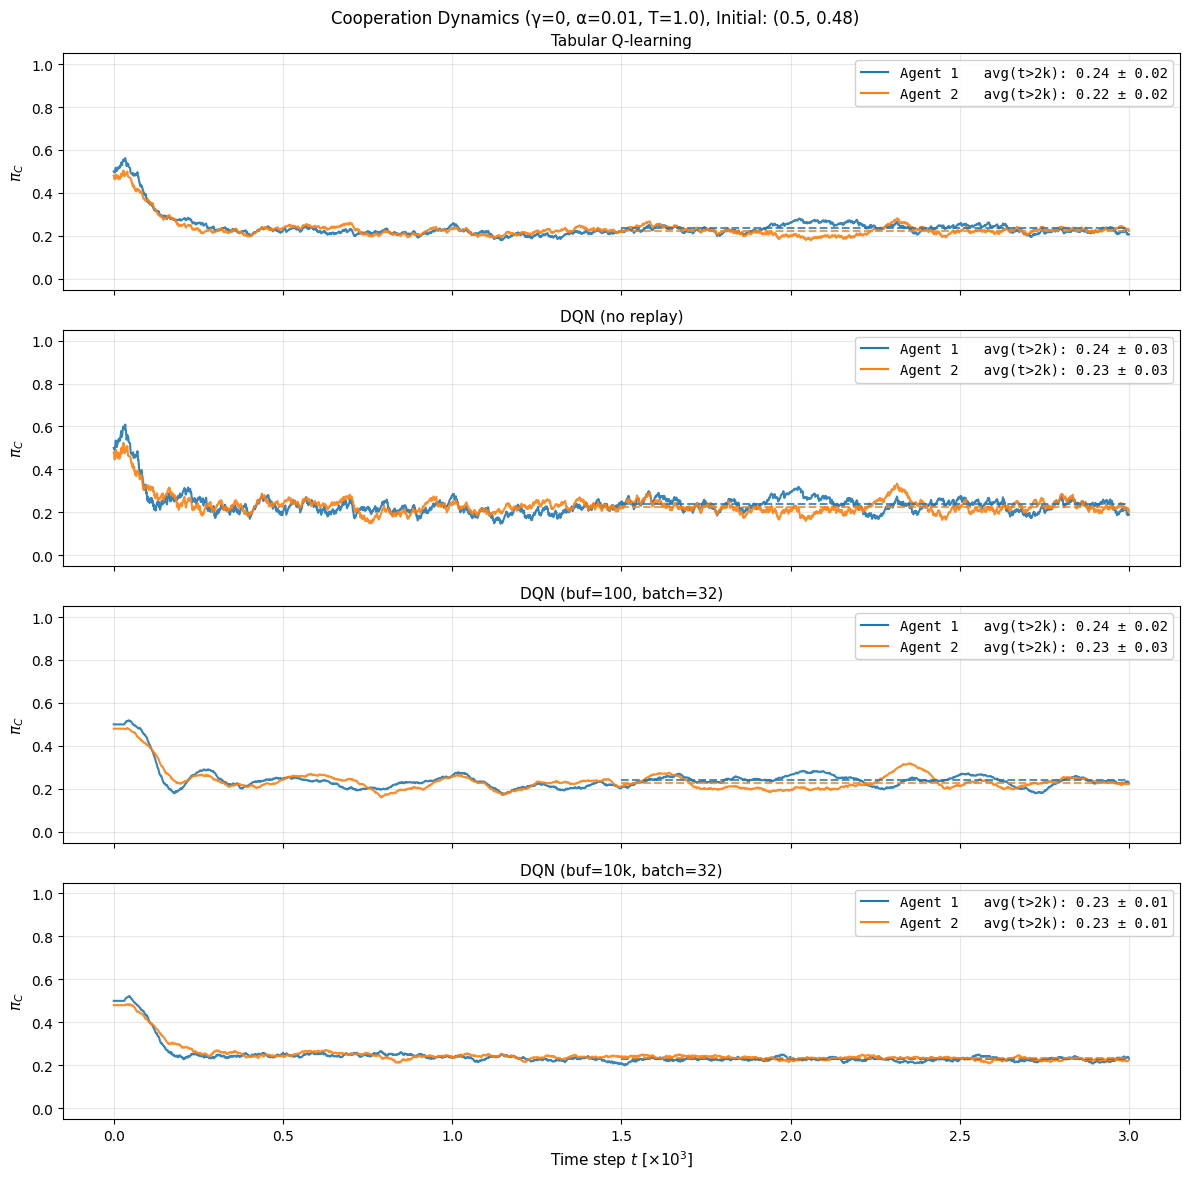

In [18]:
print(f"Running all γ=0 experiments (t={NUM_STEPS_SHORT})...\n")

all_results_g0 = {}
for config in EXPERIMENT_CONFIGS:
    print(f"Running {config['label']}...")
    if config['type'] == 'tabular':
        result = run_tabular_experiment(
            discount_factor=0.0, initial_probs=INITIAL_PROBS,
            num_time_steps=NUM_STEPS_SHORT, seed=SEED
        )
    else:
        result = run_dqn_experiment(
            discount_factor=0.0, initial_probs=INITIAL_PROBS,
            num_time_steps=NUM_STEPS_SHORT,
            buffer_size=config['buffer_size'],
            batch_size=config['batch_size'], seed=SEED
        )
    all_results_g0[config['label']] = result

print("\nDone.")

plot_comparison(
    all_results_g0,
    suptitle=f"Cooperation Dynamics (γ=0, α={LEARNING_RATE}, T={TEMPERATURE}), Initial: {INITIAL_PROBS}",
    save_path='figures/comparison_gamma_0.png',
    avg_from=1500
)

## Experiment 2: γ = 0.8 (Complex Dynamics & Replay Buffer Effect)

With $\gamma = 0.8$, tabular Q-learning exhibits complex dynamics driven by the bootstrapping term $\gamma \max_a Q(a)$ in the TD target. Both agents simultaneously chase moving targets that depend on each other's Q-values, creating a coupled, self-referential feedback loop.

We test two hypotheses:

1. **DQN without replay reproduces the complex dynamics.** If the oscillations and metastability arise from the structure of the update rule (incremental bootstrapping) rather than the tabular representation, they should also appear in a neural-network agent trained without replay.

2. **The replay buffer dampens these dynamics.** By sampling a batch of decorrelated past experiences, the replay buffer averages out the tight coupling between agents. The agent's gradient step reflects a mixture of old and recent opponent strategies, smoothing the feedback loop. Larger buffers should produce stronger damping.

In [ ]:
print(f"Running all γ=0.8 experiments (t={NUM_STEPS_LONG})...\n")

all_results_g8 = {}
for config in EXPERIMENT_CONFIGS:
    print(f"Running {config['label']}...")
    if config['type'] == 'tabular':
        result = run_tabular_experiment(
            discount_factor=0.8, initial_probs=INITIAL_PROBS,
            num_time_steps=NUM_STEPS_LONG, seed=SEED
        )
    else:
        result = run_dqn_experiment(
            discount_factor=0.8, initial_probs=INITIAL_PROBS,
            num_time_steps=NUM_STEPS_LONG,
            buffer_size=config['buffer_size'],
            batch_size=config['batch_size'], seed=SEED
        )
    all_results_g8[config['label']] = result

print("\nDone.")


Running all γ=0.8 experiments (t=100000)...

Running Tabular Q-learning...
Running DQN (no replay)...
Running DQN (buf=100, batch=32)...
Running DQN (buf=10k, batch=32)...

Done.


Saved to figures/comparison_gamma_0.8.png


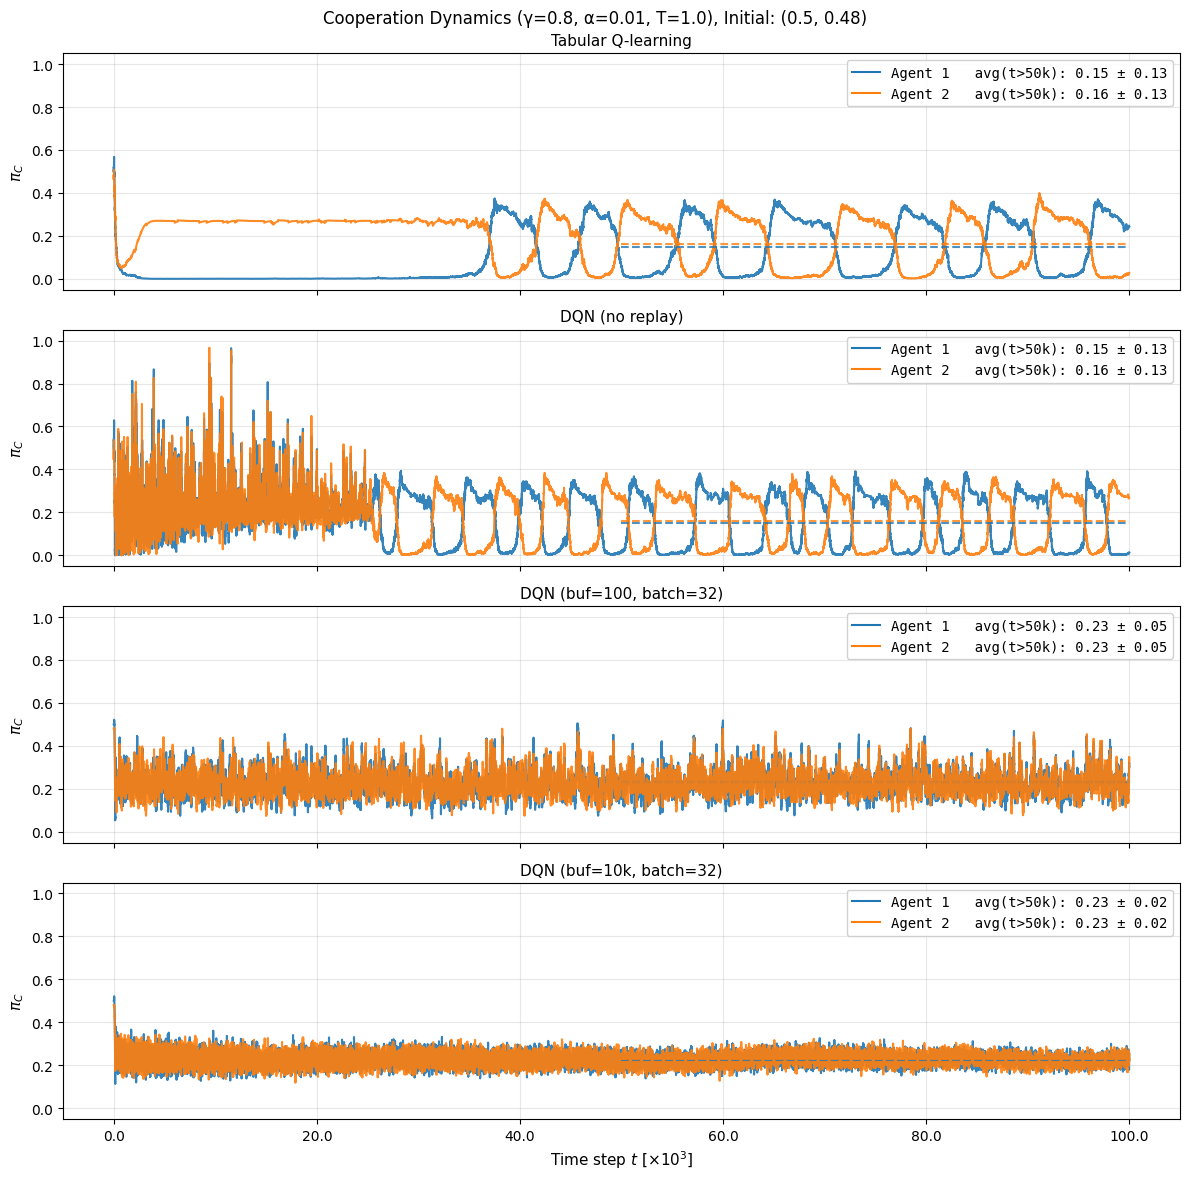

In [ ]:
plot_comparison(
    all_results_g8,
    suptitle=f"Cooperation Dynamics (γ=0.8, α={LEARNING_RATE}, T={TEMPERATURE}), Initial: {INITIAL_PROBS}",
    save_path='figures/comparison_gamma_0.8.png',
    avg_from=AVG_FROM
)

In [15]:
# Statistics table
print(f"Average Cooperation Probabilities (γ=0.8, t>{AVG_FROM//1000}k)")
print("=" * 75)
print(f"{'Method':<35} {'Avg (A1, A2)':<20} {'Std (A1, A2)':<20}")
print("-" * 75)

for name, results in all_results_g8.items():
    avg_0 = np.mean(results['prob_agent_0'][AVG_FROM:])
    avg_1 = np.mean(results['prob_agent_1'][AVG_FROM:])
    std_0 = np.std(results['prob_agent_0'][AVG_FROM:])
    std_1 = np.std(results['prob_agent_1'][AVG_FROM:])
    print(f"{name:<35} ({avg_0:.3f}, {avg_1:.3f})      ({std_0:.3f}, {std_1:.3f})")

print("-" * 75)

Average Cooperation Probabilities (γ=0.8, t>50k)
Method                              Avg (A1, A2)         Std (A1, A2)        
---------------------------------------------------------------------------
Tabular Q-learning                  (0.150, 0.162)      (0.129, 0.128)
DQN (no replay)                     (0.151, 0.158)      (0.131, 0.128)
DQN (buf=100, batch=32)             (0.230, 0.231)      (0.054, 0.053)
DQN (buf=10k, batch=32)             (0.226, 0.227)      (0.023, 0.023)
---------------------------------------------------------------------------


### Analysis

**Hypothesis 1 confirmed: DQN without replay $\approx$ tabular Q-learning.**
The top two panels are qualitatively indistinguishable. Both show the same pattern of stable oscillations: prolonged phases near defection ($\pi_C \approx 0$) interrupted by transient bursts where one agent's cooperation probability spikes toward 0.3–0.4, followed by the other agent lagging behind. The steady-state averages are nearly identical (tabular: 0.15/0.16, DQN: 0.15/0.16) with the same standard deviation (~0.13). This confirms that the complex dynamics are a property of the *incremental bootstrapping update rule*, not the tabular Q-value representation. Replacing the Q-table with a neural network (and gradient descent instead of direct Q-value updates) does not change the qualitative dynamics.

**Hypothesis 2 confirmed: the replay buffer dampens the dynamics.**
- **buf=100, batch=32:** The oscillations are eliminated. Both agents fluctuate around $\pi_C \approx 0.23$ with $\sigma \approx 0.05$, which is the same behaviour as observed for a discount factor of 0. 
- **buf=10k, batch=32:** The dynamics are further smoothed. Both agents hover tightly around $\pi_C \approx 0.23$ with $\sigma \approx 0.02$. The time series looks like stationary noise around a fixed point.

**Mechanism.** Without replay, each gradient step is computed from the current experience — which reflects both agents' most recent policies. The agents are locked in a tight feedback loop where a small policy shift by one agent immediately affects the other's next update. With a replay buffer of size $B$, each gradient step averages over a batch sampled uniformly from the last $B$ experiences, mixing interactions from many different past policy pairs. This decorrelation breaks the feedback loop: the gradient direction no longer reflects a single opponent policy but an average over recent history, which suppresses oscillatory modes.

In [ ]:
if False:  # Set to True to save results
    import os
    os.makedirs('../data/DQN', exist_ok=True)
    os.makedirs('figures', exist_ok=True)

    for gamma, all_results in [(0.0, all_results_g0), (0.8, all_results_g8)]:
        for label, results in all_results.items():
            probs = np.array([results['prob_agent_0'], results['prob_agent_1']])
            safe_label = label.replace(' ', '_').replace('(', '').replace(')', '').replace(',', '')
            filename = f"../data/DQN/probabilities_{safe_label}_gamma_{gamma}.npy"
            np.save(filename, probs)
            print(f"Saved: {filename}")

    print("\nDone!")

## Summary

The more complex learning dynamics observed in tabular multi-agent Q-learning are **not** an artifact of the tabular representation. They persist identically in a neural-network DQN agent trained without replay, indicating that the *incremental bootstrapping update* $Q(a) \leftarrow Q(a) + \alpha [r + \gamma \max Q - Q(a)]$ combined with a Boltzmann exploration policy is the essential driver.

The standard DQN replay buffer effectively **dampens** these dynamics by decorrelating updates from the current joint policy. 

### Open Questions

- **Policy gradient methods (REINFORCE, PPO):** These do not use bootstrapping ($\gamma \max Q$), so we hypothesise they would *not* exhibit the complex dynamics. REINFORCE uses sampled returns; PPO clips the surrogate objective. Neither involves the self-referential feedback that drives the oscillations.
- **Discount factor dependence:** How does varying $\gamma$ affect the damping threshold? At what buffer size do the dynamics transition from oscillatory to smooth?
- **Batch size vs. buffer size:** This notebook varies both together. Isolating their individual effects could clarify whether decorrelation (buffer) or gradient averaging (batch) is the primary damping mechanism.